# **LAB 3: Neural Networks: Feedforward Networks and the Training Process**

In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


## **Section 1 - Inside a Neural Network: From One Neuron to Gradient Descent**

## Part 1.1 - A single neuron is just a line

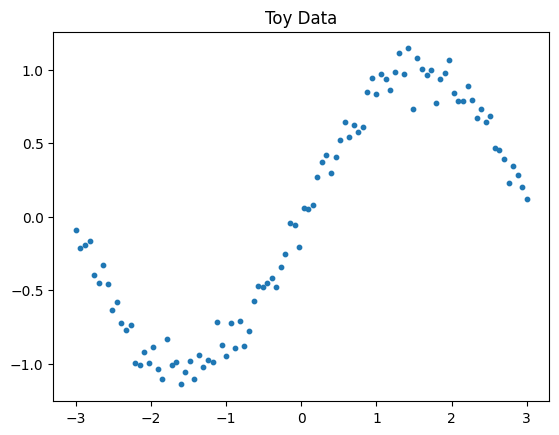

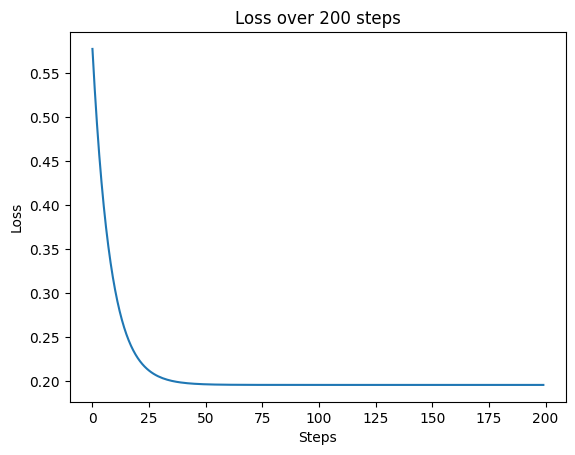

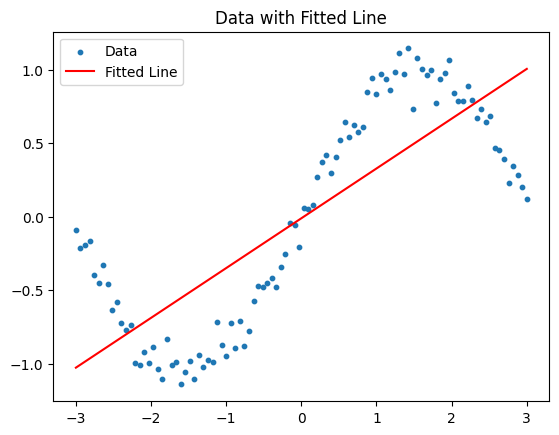

In [ ]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size = x.shape)

plt.scatter(x, y, s = 10)
plt.title("Toy Data")
plt.show()

# TODO: Initialise w and b to small random values.
w = np.random.randn() * 0.01
b = np.random.randn() * 0.01

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.
lr = 0.01
losses = []

for step in range(200):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))
    w -= lr * dw
    b -= lr * db
    losses.append(loss)

# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.
plt.plot(losses)
plt.title("Loss over 200 steps")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.show()

plt.scatter(x, y, s = 10, label = "Data")
plt.plot(x, y_hat, color = "red", label = "Fitted Line")
plt.title("Data with Fitted Line")
plt.legend()
plt.show()




1. Derive dLoss/dw on paper and include a photo or the LaTeX in this cell — does it match the code?

2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting, and WHY can a single neuron never fit a sine wave, no matter how long you train?

## Part 1.2 - Hidden layers and activations: why depth helps

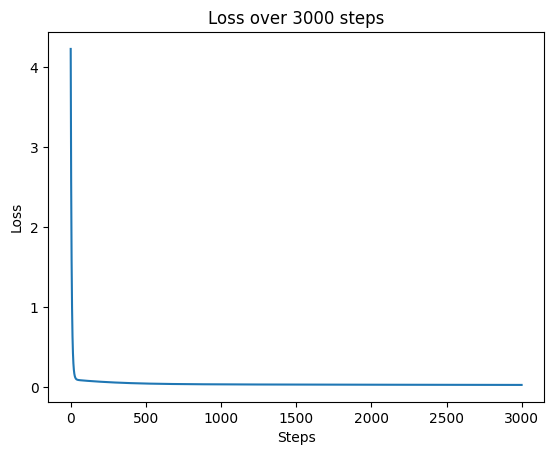

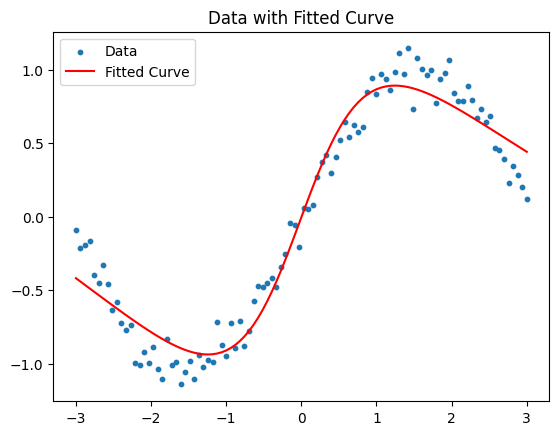

In [ ]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)
W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

lr = 0.01
losses = []

# TODO: Forward pass (keep the intermediate values — you need them for backprop):
#   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
#   h  = np.tanh(z1)        # activation
#   y_hat = h @ W2 + b2     # output, shape (100, 1)
#   loss  = np.mean((y_hat - y) ** 2)

# TODO: Backward pass (the chain rule, layer by layer):
#   d_yhat = 2 * (y_hat - y) / len(y)
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.
for step in range(3000):
    z1 = x @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - y) ** 2)

    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis = 0)
    dh  = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis = 0)

    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

    losses.append(loss)

# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
plt.plot(losses)
plt.title("Loss over 3000 steps")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.show()

plt.scatter(x, y, s = 10, label = "Data")
plt.plot(x, y_hat, color = "red", label = "Fitted Curve")
plt.title("Data with Fitted Curve")
plt.legend()
plt.show()




1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1. Explain mathematically why a stack of linear layers collapses into one linear layer.

2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few columns of h against x.) 3. This is exactly what loss.backward() will automate in Section 2. In one sentence, what is backpropagation?

## Part 1.3 - The learning rate: too cold, too hot, just right

/Users/dbbarimah/Desktop/Introduction to Artificial Intelligence/ai_env/lib/python3.9/site-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/var/folders/h_/034s64bx5w50f7602cjs11ww0000gn/T/ipykernel_42876/4124904670.py:16: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y) ** 2)
/var/folders/h_/034s64bx5w50f7602cjs11ww0000gn/T/ipykernel_42876/4124904670.py:21: RuntimeWarning: overflow encountered in matmul
  dh  = d_yhat @ W2.T
/var/folders/h_/034s64bx5w50f7602cjs11ww0000gn/T/ipykernel_42876/4124904670.py:22: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/Users/dbbarimah/Desktop/Introduction to Artificial Intelligence/ai_env/lib/python3.9/site-packages/matplotlib/scale.py:255: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


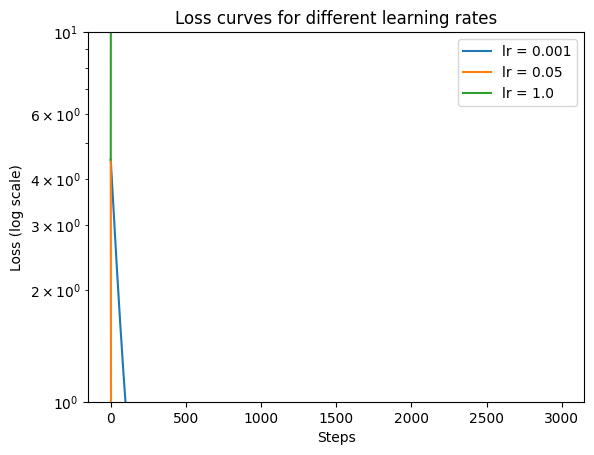

In [ ]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.
def train_toy(lr, steps = 3000):
    np.random.seed(RANDOM_STATE)
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.random.randn(8) * 0.5
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.random.randn(1) * 0.5

    losses = []

    for step in range(3000):
        z1 = x @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss = np.mean((y_hat - y) ** 2)

        d_yhat = 2 * (y_hat - y) / len(y)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis = 0)
        dh  = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = x.T @ dz1
        db1 = dz1.sum(axis = 0)

        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

        losses.append(loss)

    return losses
    
# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).
losses_slow = train_toy(lr = 0.001)
losses_good = train_toy(lr = 0.05)
losses_fast = train_toy(lr = 1.0)

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
plt.figure()
plt.plot(losses_slow, label = "lr = 0.001")
plt.plot(losses_good, label = "lr = 0.05")
plt.plot(losses_fast, label = "lr = 1.0")
plt.yscale("log")
plt.title("Loss curves for different learning rates")
plt.xlabel("Steps")
plt.ylabel("Loss (log scale)")
plt.legend()
plt.show()


Describe what each of the three curves shows. Why does a too-large learning rate make the loss explode or oscillate instead of just "learning faster"?



## **SECTION 2: A real Feedforward Network in PyTorch**

## Part 2.1 - Preprocess and split (recycled from Lab 2)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity =pd.read_csv(OBESITY_URL)

# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
obesity[binary_cols] = obesity[binary_cols].replace({'yes': 1, 'no': 0})
obesity = pd.get_dummies(obesity, columns = ['Gender', 'MTRANS'], drop_first = True)

freq_order = ['no', 'Sometimes', 'Frequently', 'Always']
ord_encoder = OrdinalEncoder(categories = [freq_order, freq_order])
obesity[['CAEC', 'CALC']] = ord_encoder.fit_transform(obesity[['CAEC', 'CALC']])

obesity['BMI'] = obesity['Weight'] / (obesity['Height'] ** 2)

label_encoder = LabelEncoder()
obesity['NObeyesdad'] = label_encoder.fit_transform(obesity['NObeyesdad'])

# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
X = obesity.drop(columns = ['NObeyesdad'])
y = obesity['NObeyesdad']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.3, stratify = y, random_state = RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.5, stratify = y_temp, random_state = RANDOM_STATE)

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests — 
#    remember Section 1, where all gradients depended on x!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader
X_train_t = torch.tensor(X_train, dtype = torch.float32)
X_val_t = torch.tensor(X_val, dtype = torch.float32)
X_test_t = torch.tensor(X_test, dtype = torch.float32)
y_train_t = torch.tensor(y_train.values, dtype = torch.float32)
y_val_t = torch.tensor(y_val.values, dtype = torch.float32)
y_test_t = torch.tensor(y_test.values, dtype = torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size = 32, shuffle = True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size = 32, shuffle = True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size = 32, shuffle = True)

print("Train: ", X_train_t.shape, "Val: ", X_val_t.shape, "Test: ", X_test_t.shape)

ModuleNotFoundError: No module named 'sklearn'